# Ensemble Learning using Voting Classifier

---

## Project

Pima Indians Diabetes Dataset Classification Models

---

## Objective

The objective of this notebook is to build and evaluate a Voting Classifier using multiple machine learning algorithms trained on the Pima Indians Diabetes Dataset.

The Voting Classifier combines the predictions of individual models to investigate whether ensemble learning can improve classification performance compared to using a single algorithm.

---

## Dataset

**Dataset:** Pima Indians Diabetes Dataset

**Source:** National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK)

The dataset contains diagnostic measurements collected from female patients of Pima Indian heritage. The objective is to predict whether a patient has diabetes based on several medical measurements.

### Features

- Pregnancies
- Glucose
- Blood Pressure
- Skin Thickness
- Insulin
- BMI
- Diabetes Pedigree Function
- Age

### Target Variable

- Outcome
  - 0 = Non-diabetic
  - 1 = Diabetic

---

## Workflow

1. Import required libraries.
2. Load the dataset.
3. Perform data preprocessing.
4. Split the dataset into training and testing sets.
5. Standardise the feature variables.
6. Train the individual classification models.
7. Build a Hard Voting Classifier.
8. Evaluate the Hard Voting Classifier.
9. Build a Soft Voting Classifier.
10. Evaluate the Soft Voting Classifier.
11. Compare the ensemble models with the individual classifiers.
12. Draw conclusions.

## Key Concepts

This notebook demonstrates:

- Ensemble Learning
- Voting Classifier
- Hard Voting
- Soft Voting
- Model Comparison
- Classification Metrics

# LIBRARIES 

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
# import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Individual machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Ensemble Learning
from sklearn.ensemble import VotingClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# LOAD DATASET AND OVERVIEW

In [4]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# FEATURES AND TARGET

In [6]:
# Features
X = df.drop("Outcome", axis=1)
# Target
y = df["Outcome"]

# TRAIN AND TEST SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# FEATURE SCALING
## Why Feature Scaling?

The Voting Classifier combines multiple machine learning algorithms. Some of these algorithms, such as K-Nearest Neighbours (KNN) and Support Vector Machines (SVM), are sensitive to the scale of the input features.

StandardScaler standardises each feature by removing the mean and scaling it to unit variance. The scaler is fitted only on the training data to prevent data leakage and then applied to both the training and testing datasets.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# TRAIN THE INDIVIDUAL MODELS

In [13]:
log_model = LogisticRegression(random_state=42)
# k=18 was used because it was our best performer in the previous KNN experiment
knn_model = KNeighborsClassifier(n_neighbors=18) 
svm_model = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)


## Why These Models Were Selected

Three machine learning algorithms were selected for the Voting Classifier:

- Logistic Regression
- K-Nearest Neighbours (K = 18)
- Support Vector Machine (Linear Kernel)

These models were chosen because each performed well during previous experiments on the Pima Indians Diabetes Dataset and represents a different approach to classification.

- **Logistic Regression** is a linear probabilistic model that predicts class membership by estimating probabilities.
- **K-Nearest Neighbours (K = 18)** is a distance-based algorithm that classifies a sample according to the majority class of its nearest neighbours. A value of **K = 18** was selected because it produced the best performance during hyperparameter tuning.
- **Support Vector Machine (Linear Kernel)** is a margin-based classifier that identifies the optimal decision boundary separating the two classes.

Using models with different learning strategies increases the diversity of the ensemble. Since each algorithm learns patterns differently, their individual strengths can complement one another, potentially producing more robust and reliable predictions than any single model alone.

# HARD VOTING CLASSIFIER

In [15]:
hard_voting = VotingClassifier(
    estimators=[
        ("lr", log_model),
        ("knn", knn_model),
        ("svm", svm_model)
    ],
    voting="hard"
)

hard_voting.fit(X_train_scaled, y_train)

C:\Users\HP\miniconda3\envs\ml\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('knn', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...ndom_state=42), KNeighborsCla..._neighbors=18), SVC(kernel='l...ndom_state=42)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,8


## Why Is Feature Scaling Used Here?

Although Logistic Regression can perform well without feature scaling, the Voting Classifier also includes K-Nearest Neighbours (KNN) and Support Vector Machine (SVM), both of which are highly sensitive to the scale of the input features.

To ensure that all models receive data on the same scale and to maintain a consistent preprocessing pipeline, the features are standardised using `StandardScaler` before training the ensemble.

This allows distance-based algorithms such as KNN and SVM to perform optimally while also providing a uniform input for the Voting Classifier.

# MAKE PREDICTIONS: HARD VOTING

In [18]:
# Hard Voting Prediction
y_pred_hard = hard_voting.predict(X_test_scaled)

# HARD VOTING MODEL EVALUATION

In [19]:
# Hard Voting Accuracy Evaluation
hard_accuracy = accuracy_score(y_test, y_pred_hard)
print(f"Accuracy: {hard_accuracy:.2f}")

Accuracy: 0.77


Confusion Matrix: [[81 18]
 [18 37]]


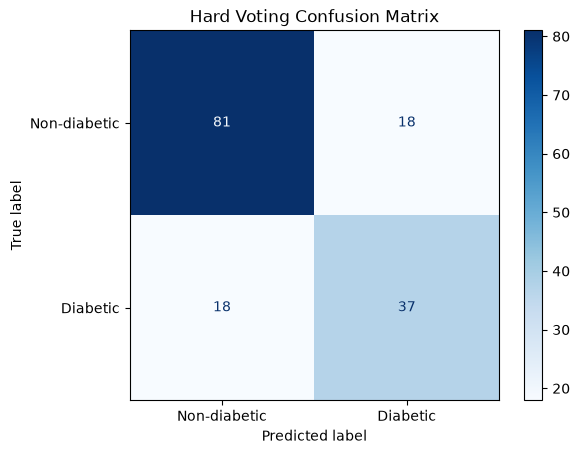

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_hard)
print(f"Hard Voting Confusion Matrix: {cm}")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-diabetic", "Diabetic"]
)
disp.plot(cmap="Blues")
plt.title("Hard Voting Confusion Matrix")
plt.show()

In [23]:
#Classification Report
print(classification_report(y_test, y_pred_hard))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        99
           1       0.67      0.67      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



# HARD VOTING CONCLUSION
## Hard Voting Results

The Hard Voting Classifier  an accuracy of **77%**, outperforming the individual classifiers used in the ensemble.

The model correctly classified 81 non-diabetic patients and 37 diabetic patients, while misclassifying 18 patients from each class.

These results suggest that combining multiple classifiers through majority voting can produce a more robust model than relying on a single algorithm, as each model contributes its own perspective to the final prediction.

# SOFT VOTING CLASSIFIER

In [27]:
soft_voting = VotingClassifier(
    estimators=[
        ("lr", log_model),
        ("knn", knn_model),
        ("svm", svm_model)
    ],
    voting="soft"
)

soft_voting.fit(X_train_scaled, y_train)

C:\Users\HP\miniconda3\envs\ml\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('knn', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...ndom_state=42), KNeighborsCla..._neighbors=18), SVC(kernel='l...ndom_state=42)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,8


# SOFT VOTING PREDICTION

In [31]:
y_pred_soft = soft_voting.predict(X_test_scaled)

# SOFT VOTING MODEL EVALUATION

In [33]:
# Soft Voting Accuracy Evaluation
soft_accuracy = accuracy_score(y_test, y_pred_soft)
print(f"Accuracy: {soft_accuracy:.2f}")

Accuracy: 0.77


Soft Voting Confusion Matrix: [[84 15]
 [20 35]]


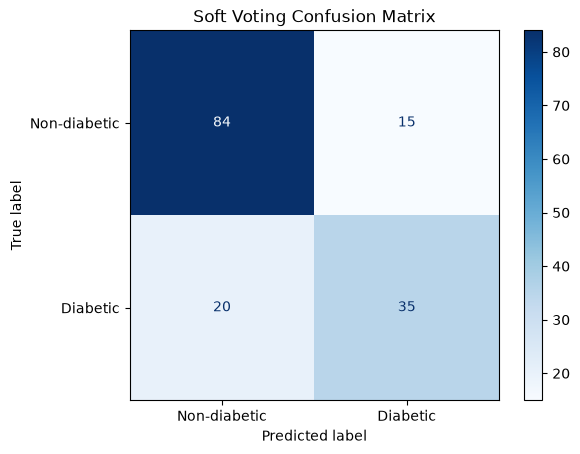

In [35]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_soft)
print(f"Soft Voting Confusion Matrix: {cm}")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-diabetic", "Diabetic"]
)
disp.plot(cmap="Blues")
plt.title("Soft Voting Confusion Matrix")
plt.show()

In [36]:
# Classification Report
print(classification_report(y_test, y_pred_soft))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83        99
           1       0.70      0.64      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.75       154
weighted avg       0.77      0.77      0.77       154



In [37]:
# ROC_AUC 
y_prob_soft = soft_voting.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_soft)

print("ROC-AUC Score:", round(roc_auc, 2))

ROC-AUC Score: 0.81


## Why Was ROC-AUC Calculated Only for the Soft Voting Classifier?

ROC-AUC measures how well a model separates the two classes using **prediction probabilities**.

The Hard Voting Classifier only uses the final predictions (0 or 1) from each model to make a majority vote. Since it does not use prediction probabilities when making its decision, ROC-AUC is not appropriate for evaluating its performance.

The Soft Voting Classifier, however, averages the prediction probabilities from all the individual models before making a final prediction. Because these probabilities are available, the model can be evaluated using ROC-AUC.

For this reason, ROC-AUC was calculated only for the Soft Voting Classifier.

# SOFT VOTING CONCLUSION
### Soft Voting Results

The Soft Voting Classifier achieved an overall accuracy of **77%**, matching the performance of the Hard Voting Classifier.

The model correctly classified 84 non-diabetic patients and 35 diabetic patients. It also achieved a **ROC-AUC score of 0.81**, indicating a good ability to distinguish between diabetic and non-diabetic patients based on prediction probabilities.

Although Soft Voting produced slightly higher precision, it identified fewer diabetic patients than the Hard Voting Classifier. This demonstrates that Soft Voting favoured more confident predictions, resulting in fewer false positives but a slightly lower recall.

# FINAL CONCLUSION
# Final Conclusion

This notebook explored two ensemble learning techniques: Hard Voting and Soft Voting, using Logistic Regression, K-Nearest Neighbours (K = 18), and Support Vector Machine as the base classifiers.

Both ensemble methods achieved an overall accuracy of **77%**, demonstrating that combining multiple machine learning models can produce stable and reliable predictions.

Hard Voting achieved a slightly higher recall by correctly identifying more diabetic patients, while Soft Voting produced a slightly higher precision and an ROC-AUC score of **0.81**, showing strong discriminative performance based on prediction probabilities.

Overall, this project demonstrated that ensemble learning can improve the robustness of machine learning models by combining different classification algorithms. It also highlighted the importance of evaluating models using multiple performance metrics rather than relying solely on accuracy, as different ensemble methods may perform better depending on the specific objective of the problem.